# Import Required Libraries
Import pandas and other necessary libraries for data manipulation and file handling.

In [6]:
import pandas as pd
from pathlib import Path

## Set Data Path
Define the path to the interim folder containing the parquet files.

In [2]:
data_path = Path('../data/interim/')

## Load Hip Provider Data
Use pandas to read the hip-provider.parquet file and store it in a DataFrame.

In [3]:
hip_df = pd.read_parquet(data_path / 'hip-provider.parquet')

## Load Knee Provider Data
Use pandas to read the knee-provider.parquet file and store it in a DataFrame.

In [4]:
knee_df = pd.read_parquet(data_path / 'knee-provider.parquet')

## Verify Data Loading
Display the shape, column names, and first few rows of both DataFrames to confirm successful data loading.

In [5]:
print("Hip Provider Data:")
print(f"Shape: {hip_df.shape}")
print(f"Columns: {hip_df.columns.tolist()}")
print(f"\nFirst few rows:\n{hip_df.head()}")

print("\n" + "="*80 + "\n")

print("Knee Provider Data:")
print(f"Shape: {knee_df.shape}")
print(f"Columns: {knee_df.columns.tolist()}")
print(f"\nFirst few rows:\n{knee_df.head()}")

Hip Provider Data:
Shape: (124844, 81)
Columns: ['provider_code', 'procedure', 'revision_flag', 'year', 'age_band', 'gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_living_arrangements', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility', 't0_self_care', 't0_activity', 't0_discomfort', 't0_anxiety', 't0_eq5d_index_profile', 't0_eq5d_index', 't1_assisted', 't1_assisted_by', 't1_living_arrangements', 't1_disability', 't1_mobility', 't1_self_care', 't1_activity', 't1_discomfort', 't1_anxiety', 't1_satisfaction', 't1_sucess', 't1_allergy', 't1_bleeding', 't1_wound', 't1_urine', 't1_further_surgery', 't1_readmitted', 't1_eq5d_index_profile', 't1_eq5d_index', 'ohs_eq5d_index_t1_predicted', 't0_eq_vas', 't1_eq_vas', 'ohs_eq_vas_t1_predicted', 'ohs_t0_pain', 'ohs_t0_sudden_pain', 'ohs_t0_night_pain', 'oh

## OKS/OHS Improvement Analysis
Calculate and visualize the improvement in scores (t1 - t0) for both knee and hip procedures.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate improvement for hip data (OHS: Oxford Hip Score)
hip_df['ohs_improvement'] = hip_df['ohs_t1_score'] - hip_df['ohs_t0_score']

# Calculate improvement for knee data (OKS: Oxford Knee Score)
knee_df['oks_improvement'] = knee_df['oks_t1_score'] - knee_df['oks_t0_score']

# Remove NaN values
hip_improvement = hip_df['ohs_improvement'].dropna().sort_values().values
knee_improvement = knee_df['oks_improvement'].dropna().sort_values().values

print(f"Hip OHS Improvement Statistics:")
print(f"  Mean: {hip_df['ohs_improvement'].mean():.2f}")
print(f"  Median: {hip_df['ohs_improvement'].median():.2f}")
print(f"  Std Dev: {hip_df['ohs_improvement'].std():.2f}")
print(f"  Count: {hip_df['ohs_improvement'].notna().sum()}")

print(f"\nKnee OKS Improvement Statistics:")
print(f"  Mean: {knee_df['oks_improvement'].mean():.2f}")
print(f"  Median: {knee_df['oks_improvement'].median():.2f}")
print(f"  Std Dev: {knee_df['oks_improvement'].std():.2f}")
print(f"  Count: {knee_df['oks_improvement'].notna().sum()}")

Hip OHS Improvement Statistics:
  Mean: 21.94
  Median: 23.00
  Std Dev: 10.20
  Count: 122033

Knee OKS Improvement Statistics:
  Mean: 16.89
  Median: 17.00
  Std Dev: 9.86
  Count: 135051


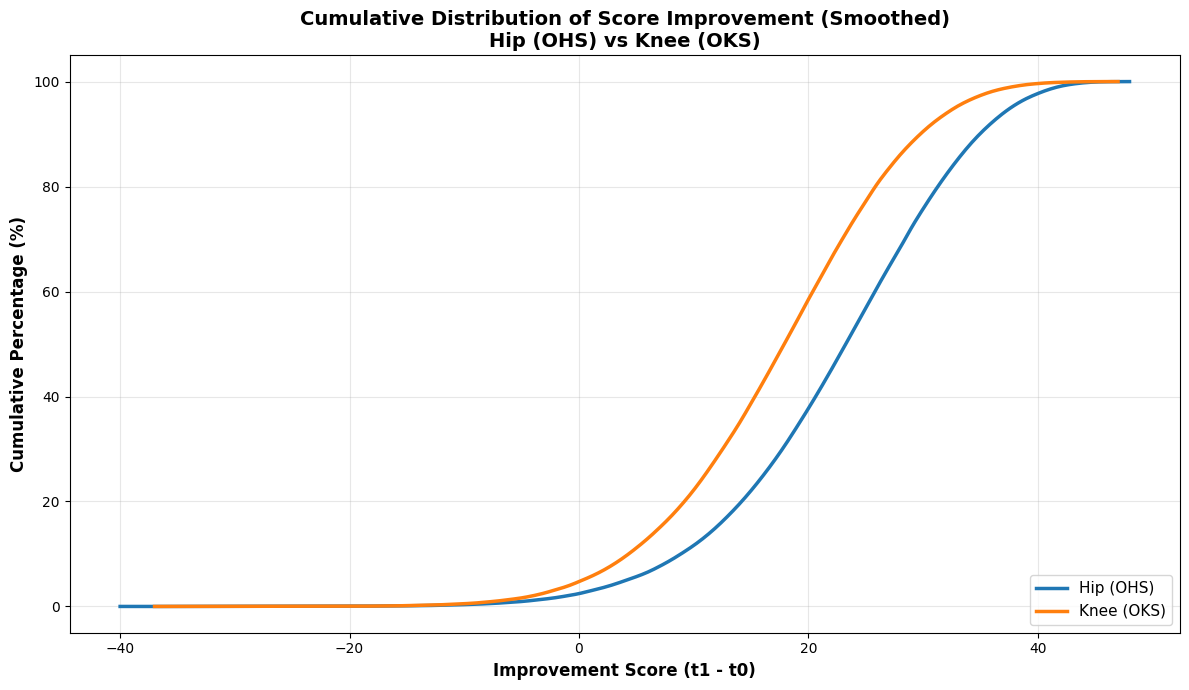


Improvement ranges:
Hip OHS: -40 to 48
Knee OKS: -37 to 47


In [11]:
from scipy.interpolate import interp1d

# Create cumulative distribution graphs with smoothing
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate cumulative percentiles
hip_cumulative = np.arange(1, len(hip_improvement) + 1) / len(hip_improvement) * 100
knee_cumulative = np.arange(1, len(knee_improvement) + 1) / len(knee_improvement) * 100

# Remove duplicates and keep unique sorted values
hip_unique_idx = np.unique(hip_improvement, return_index=True)[1]
hip_unique_idx = np.sort(hip_unique_idx)
hip_x_unique = hip_improvement[hip_unique_idx]
hip_y_unique = hip_cumulative[hip_unique_idx]

knee_unique_idx = np.unique(knee_improvement, return_index=True)[1]
knee_unique_idx = np.sort(knee_unique_idx)
knee_x_unique = knee_improvement[knee_unique_idx]
knee_y_unique = knee_cumulative[knee_unique_idx]

# Create smooth interpolation functions using cubic splines
hip_smooth = interp1d(hip_x_unique, hip_y_unique, kind='cubic', fill_value='extrapolate')
knee_smooth = interp1d(knee_x_unique, knee_y_unique, kind='cubic', fill_value='extrapolate')

# Generate smooth curves
hip_smooth_x = np.linspace(hip_improvement.min(), hip_improvement.max(), 500)
knee_smooth_x = np.linspace(knee_improvement.min(), knee_improvement.max(), 500)
hip_smooth_y = hip_smooth(hip_smooth_x)
knee_smooth_y = knee_smooth(knee_smooth_x)

# Plot smoothed cumulative distributions
ax.plot(hip_smooth_x, hip_smooth_y, label='Hip (OHS)', linewidth=2.5, color='#1f77b4')
ax.plot(knee_smooth_x, knee_smooth_y, label='Knee (OKS)', linewidth=2.5, color='#ff7f0e')

ax.set_xlabel('Improvement Score (t1 - t0)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Distribution of Score Improvement (Smoothed)\nHip (OHS) vs Knee (OKS)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

print(f"\nImprovement ranges:")
print(f"Hip OHS: {hip_improvement.min():.0f} to {hip_improvement.max():.0f}")
print(f"Knee OKS: {knee_improvement.min():.0f} to {knee_improvement.max():.0f}")

## Zoomed-in View: Improvement 0-20
Detailed view of improvement scores in the 0-20 range.

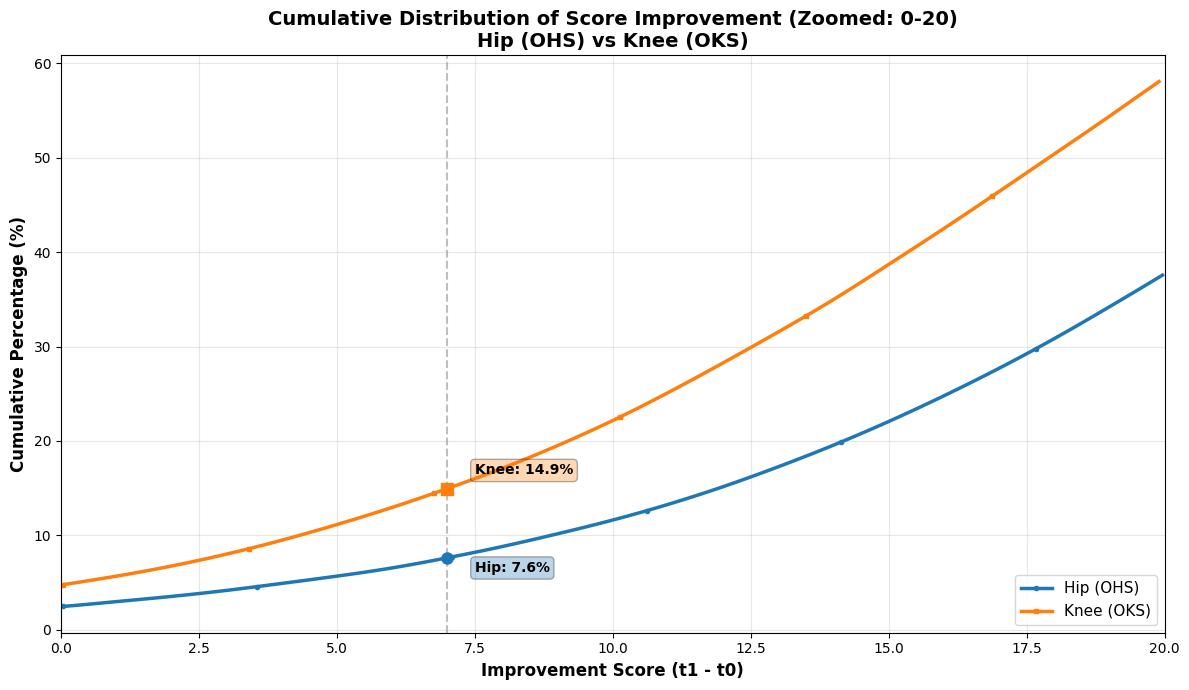

At improvement score = 7 points:
  Hip (OHS): 7.61%
  Knee (OKS): 14.95%


In [14]:
# Create zoomed-in plot for improvement 0-20 range
fig, ax = plt.subplots(figsize=(12, 7))

# Define zoom range
zoom_min, zoom_max = 0, 20

# Filter and smooth within zoomed range
hip_mask = (hip_smooth_x >= zoom_min) & (hip_smooth_x <= zoom_max)
knee_mask = (knee_smooth_x >= zoom_min) & (knee_smooth_x <= zoom_max)

hip_zoom_x = hip_smooth_x[hip_mask]
hip_zoom_y = hip_smooth_y[hip_mask]
knee_zoom_x = knee_smooth_x[knee_mask]
knee_zoom_y = knee_smooth_y[knee_mask]

# Plot zoomed cumulative distributions
ax.plot(hip_zoom_x, hip_zoom_y, label='Hip (OHS)', linewidth=2.5, color='#1f77b4', marker='o', markersize=3, markevery=20)
ax.plot(knee_zoom_x, knee_zoom_y, label='Knee (OKS)', linewidth=2.5, color='#ff7f0e', marker='s', markersize=3, markevery=20)

# Calculate percentages at improvement score = 7
improvement_point = 7
hip_pct_at_7 = hip_smooth(improvement_point)
knee_pct_at_7 = knee_smooth(improvement_point)

# Add vertical line at x=7
ax.axvline(x=improvement_point, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Add text annotations showing exact percentages at improvement = 7
ax.plot(improvement_point, hip_pct_at_7, 'o', color='#1f77b4', markersize=8)
ax.plot(improvement_point, knee_pct_at_7, 's', color='#ff7f0e', markersize=8)

# Add text labels for the percentages
ax.text(improvement_point + 0.5, hip_pct_at_7 - 1.5, f'Hip: {hip_pct_at_7:.1f}%', 
        fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='#1f77b4', alpha=0.3))
ax.text(improvement_point + 0.5, knee_pct_at_7 + 1.5, f'Knee: {knee_pct_at_7:.1f}%', 
        fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='#ff7f0e', alpha=0.3))

ax.set_xlabel('Improvement Score (t1 - t0)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Distribution of Score Improvement (Zoomed: 0-20)\nHip (OHS) vs Knee (OKS)', fontsize=14, fontweight='bold')
ax.set_xlim(zoom_min, zoom_max)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

print(f"At improvement score = 7 points:")
print(f"  Hip (OHS): {hip_pct_at_7:.2f}%")
print(f"  Knee (OKS): {knee_pct_at_7:.2f}%")